# Status

I have been focusing on fixing stretch first -- similar functioning 
1. run single test

# Case Study: Bayesian logistic regression with a Laplace prior via SOUL with PAIES step and the walk move.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [2]:
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))  
sys.path.append(project_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from algorithms import sig, log_p_laplace, soul_walk_fast_decay, soul_walk_fast_decay_v2
#pip_ula, prox_pgd, proximal_map_laplace_iteration_total, pipgla, proximal_map_laplace_approx_total
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

os.chdir(project_root)

# Obtain synthetic dataset for Laplace prior case

In [3]:
from scipy.stats import laplace, bernoulli
# Data and design matrix
np.random.seed(3)
design_matrix = np.random.uniform(low = -1.0, high = 1.0, size = (900, 50))
x_unknown = laplace.rvs(loc = -4, size = (50, 1))
parameter_bernoulli = sig(np.matmul(design_matrix, x_unknown))
data_experiment = bernoulli.rvs(np.array(parameter_bernoulli[:, 0]), size = 900)
labels = np.expand_dims(data_experiment, axis=1)
theta_true = -4

# SOUL PAIES algorithm with walk move

In [9]:
# One run test
# --- SOUL Optimization Setup ---
D = 50       # Dimensionality of latent variables (x)
T = 800      # Outer optimization steps
M = 30       # MH steps per outer loop
B = 5       # Burn-in steps
delta_step = 0.2 #0.08
#proposal_std = 0.05
b_scale = 1.0 # Scale parameter for the Laplace prior

# Initializations

N = 80 #100 # Number of walkers
x0_N = np.random.normal(0, 0.1, (D, N)) # Initialize x0_N with some slight noise
#x0_M = np.zeros((D, 1))   # Initial latent variables vector
th0 = np.array([[-15.0]]) 


# Run the adapted algorithm
th_list, x_samples = soul_walk_fast_decay_v2(
    log_p=log_p_laplace,
    th0=th0,
    x0_N=x0_N,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    #D=D,
    delta_step=delta_step,
    gamma= 0.999995,
    s=4
)

print("Final estimated theta:", th_list[-1][0, 0])
print("True theta (loc parameter): -4.0")

t=50, theta=[[-5.00176677]]
t=100, theta=[[-1.45318196]]
t=150, theta=[[-1.47679325]]
t=200, theta=[[-1.64287193]]
t=250, theta=[[-2.58741789]]
t=300, theta=[[-2.92680768]]
t=350, theta=[[-3.15239732]]
t=400, theta=[[-3.31199454]]
t=450, theta=[[-3.4225401]]
t=500, theta=[[-3.57756038]]
t=550, theta=[[-3.66172962]]
t=600, theta=[[-3.73662656]]
t=650, theta=[[-3.77111601]]
t=700, theta=[[-3.81647801]]
t=750, theta=[[-3.91241725]]
t=800, theta=[[-3.96771923]]
Final estimated theta: -3.9677192301929076
True theta (loc parameter): -4.0


t=50, theta=[[-1.26827]]
t=100, theta=[[-1.748308]]
t=150, theta=[[-2.448204]]
t=200, theta=[[-2.857998]]
t=250, theta=[[-3.168752]]
t=300, theta=[[-3.412282]]
t=350, theta=[[-3.55677]]
t=400, theta=[[-3.697162]]
t=450, theta=[[-3.836612]]
t=500, theta=[[-3.930684]]
t=550, theta=[[-3.995142]]
t=600, theta=[[-4.061828]]
t=650, theta=[[-4.121346]]
t=700, theta=[[-4.165368]]
t=750, theta=[[-4.226372]]
t=800, theta=[[-4.319562]]
t=850, theta=[[-4.332006]]
t=900, theta=[[-4.38485]]
t=950, theta=[[-4.39245]]
t=1000, theta=[[-4.393056]]
t=50, theta=[[-10.074708]]
t=100, theta=[[-8.044556]]
t=150, theta=[[-7.235862]]
t=200, theta=[[-7.063374]]
t=250, theta=[[-6.95874]]
t=300, theta=[[-6.819496]]
t=350, theta=[[-6.679288]]
t=400, theta=[[-6.538558]]
t=450, theta=[[-6.414996]]
t=500, theta=[[-6.243452]]
t=550, theta=[[-6.141028]]
t=600, theta=[[-6.023708]]
t=650, theta=[[-5.910554]]
t=700, theta=[[-5.837194]]
t=750, theta=[[-5.761102]]
t=800, theta=[[-5.686466]]
t=850, theta=[[-5.631352]]
t=900,

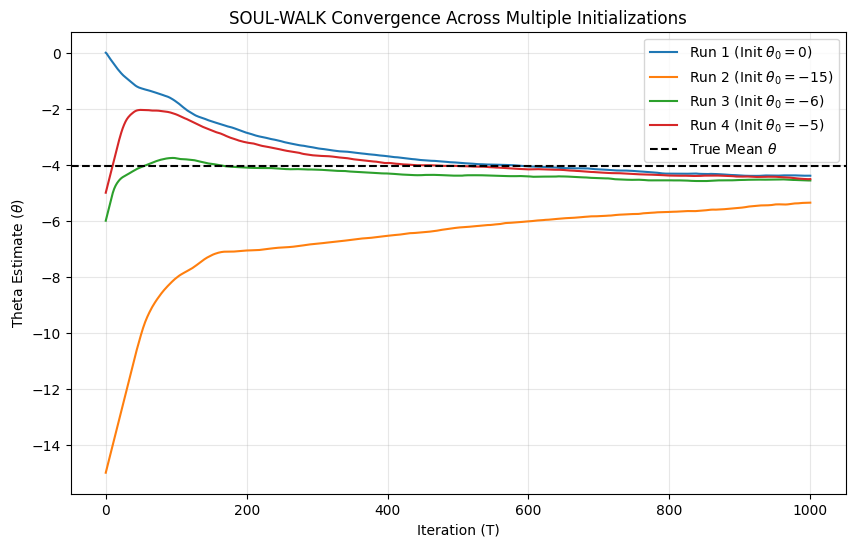

In [5]:
#  Without parallelisation

# --- Experiment Parameters ---
T = 1000  # Outer steps 
B = 5               
M = 30 

# Tuning hyper-parameters for SOUL-MH
delta_step = 0.1    # Theta learning rate
b_scale = 1.0        # Laplace prior scale

fig = plt.figure(figsize=(10, 6))
theta_walk = []
X_walk = []

for run_idx in range(4):
    # Randomly initialize theta0 between -15 and 10
    theta0_val = np.random.randint(-15, 10)
    th0 = np.array([[float(theta0_val)]])
    
    # Initialize X0 drawn from Gaussian centered at theta0, shape (D, M)
    # where D is feature dimension (50 from Paula's dataset)
    D = design_matrix.shape[1]
    X0_M = np.random.normal(loc=theta0_val, scale=1.0, size=(D, M))
    
    th_list, x_values = soul_walk_fast_decay_v2(
    log_p=log_p_laplace,
    th0=th0,
    x0_N=x0_N,
    y_l=design_matrix,
    y_f=labels,
    T=T,
    M=M,
    B=B,
    #D=D,
    delta_step=delta_step
    #proposal_std=proposal_std,
    #b=b_scale,
    #gamma=0.9999995
)
    
    # Extract flattened array of theta trajectory across iterations
    th_trajectory = np.array([t[0, 0] for t in th_list])
    
    theta_walk.append(th_trajectory)
    X_walk.append(x_values)
    
    # Plot trajectory for this run
    plt.plot(th_trajectory, label=f'Run {run_idx + 1} (Init $\\theta_0={theta0_val}$)')

# Reference line for ground truth mean
plt.axhline(y=np.mean(x_unknown), color='black', linestyle='dashed', label='True Mean $\\theta$')

plt.title('SOUL-WALK Convergence Across Multiple Initializations')
plt.xlabel('Iteration (T)')
plt.ylabel('Theta Estimate ($\\theta$)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()
fig.savefig('soul_WALK_convergence.pdf', format='pdf')

In [ ]:
from joblib import Parallel, delayed

# tried parallelisation to go faster >> error..

"""

# --- Experiment Parameters ---
T = 900  # Outer steps 
B = 5               
M = 30 #30

N=70

# Tuning hyper-parameters for SOUL-MH
delta_step = 0.1 #0.08    # Theta learning rate
b_scale = 1.0        # Laplace prior scale
#gamma_val = 0.9995

def run_single_soul_walk(run_idx):
    theta0_val = np.random.randint(-15, 10)
    th0 = np.array([[float(theta0_val)]])
    D = design_matrix.shape[1]
    X0_M = np.random.normal(loc=theta0_val, scale=1.0, size=(D, N))
    #x0_N = np.random.normal(0, 0.1, (D, N))

    th_list, x_values = soul_walk_fast(
        log_p=log_p_laplace,
        th0=th0,
        x0_N=X0_M,
        y_l=design_matrix,
        y_f=labels,
        T=T,
        M=M,
        B=B,
        delta_step=delta_step,
        b=b_scale,
        gamma = 0.999995
    )
    th_trajectory = np.array([t[0, 0] for t in th_list])
    return run_idx, theta0_val, th_trajectory, x_values


# Run all 7 initializations in parallel across available CPU cores (leave at least one free so the computer stays responsive)
results = Parallel(n_jobs=-2)(
    delayed(run_single_soul_walk)(i) for i in range(7)
)

# Plot all 7 runs on one figure
fig = plt.figure(figsize=(10, 6))

theta_soul = []
X_soul = []

# Loop over the parallel results and add each line to the same plot
for run_idx, theta0_val, th_trajectory, x_values in results:
    theta_soul.append(th_trajectory)
    X_soul.append(x_values)

    plt.plot(
        th_trajectory,
        label=f"Run {run_idx + 1} (Init $\\theta_0={theta0_val}$)",
    )

# Reference line for ground truth
plt.axhline(
    y=np.mean(x_unknown),
    color="black",
    linestyle="dashed",
    label="True Mean $\\theta$",
)

plt.title("SOUL-WALK Convergence Across Multiple Initializations") #$\\gamma = 0.9995 $
plt.xlabel("Iteration (T)")
plt.ylabel("Theta Estimate ($\\theta$)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.show()
fig.savefig("soul_walk_convergence_parallel.pdf", format="pdf")

"""

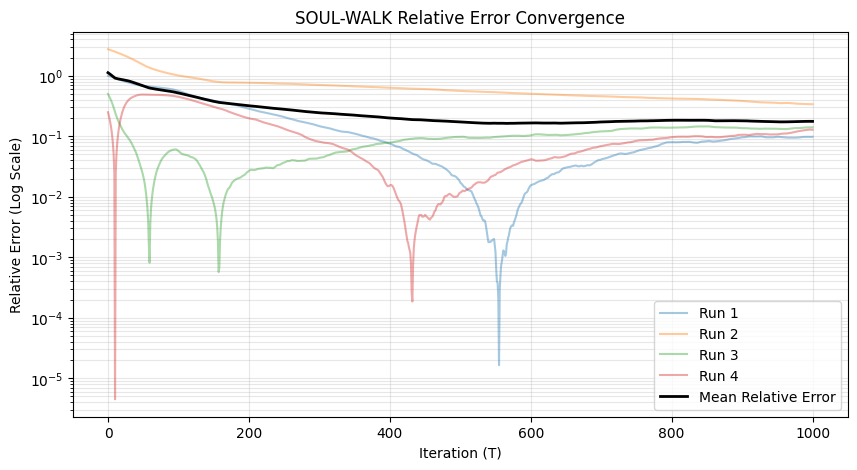

In [6]:
# Convert list of trajectories into a 2D numpy array of shape (num_runs, T + 1)
theta_walk_arr = np.array(theta_walk)

# Compute relative error trajectory for each run
relative_error_trajectories = np.abs(theta_walk_arr - theta_true) / np.abs(
    theta_true
)

# Mean relative error across all runs per iteration step
mean_relative_error_per_step = np.mean(relative_error_trajectories, axis=0)

# Plot Relative Error over iterations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for idx, err_traj in enumerate(relative_error_trajectories):
    plt.plot(err_traj, alpha=0.4, label=f"Run {idx + 1}")

plt.plot(
    mean_relative_error_per_step,
    color="black",
    linewidth=2,
    label="Mean Relative Error",
)
plt.yscale("log")  # Log scale highlights convergence speed clearly
plt.title("SOUL-WALK Relative Error Convergence")
plt.xlabel("Iteration (T)")
plt.ylabel("Relative Error (Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# More tests (DO NOT RUN)

In [ ]:
# this is to try to batch log_p_laplace (vecteurs)
th = np.array([[-8.0]]) 
D=50

X_test = np.random.normal(0, 0.1, (D, 5))
batched = log_p_laplace_batched(th, X_test, design_matrix, labels)
looped = np.array([log_p_laplace(th, X_test[:, i:i+1], design_matrix, labels) for i in range(5)])
print(np.allclose(batched, looped))   # should print True

In [ ]:
print("design_matrix:", design_matrix.shape)
print("labels:", labels.shape)